<a href="https://colab.research.google.com/github/robertbarcik/genai-in-python-tutorial/blob/main/2_basic_project_examples/6_converting_text_into_audio_fairytale_example/6_converting_text_to_audio_fairytale_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fairytale Studio

One story idea, three ways to bring it to life. You give a one-line idea; the app **writes** a fairytale, **narrates** it in a voice, and **illustrates** it with a picture. It is the same basic API call you already know, pointed at three different outputs.

## Setup

Install the library and connect the client to your API key.

In [1]:
# Colab installs what this notebook needs here. Running locally? `pip install -r requirements.txt` in the course folder already covers it.
%pip install -q openai==2.28.0

import os
from openai import OpenAI

# Key from Colab secrets, an environment variable, or a prompt, in that order.
try:
    from google.colab import userdata
    api_key = userdata.get("OPENAI_API_KEY")
except Exception:
    api_key = os.environ.get("OPENAI_API_KEY")
if not api_key:
    from getpass import getpass
    api_key = getpass("OpenAI API key: ")

client = OpenAI(api_key=api_key)
TEXT_MODEL = "gpt-5-nano"

Note: you may need to restart the kernel to use updated packages.


## The two things you change

Everything below runs from these. Change them, re-run, and you get a brand new story, voice, and picture.

In [2]:
idea = "a shy dragon who is afraid of the dark and makes friends with a firefly"
voice = "fable"  # alloy, echo, fable, onyx, nova, shimmer

## The one call

This is the whole engine. One call turns a one-line idea into a finished story. Everything after this just does something with the text it returns.

In [3]:
story = client.responses.create(
    model=TEXT_MODEL,
    input=[
        {"role": "developer", "content":
            "You write short, warm bedtime fairytales for young children. "
            "About 150 words, gentle and a little funny, with a happy ending."},
        {"role": "user", "content": f"Write a fairytale about {idea}."},
    ],
).output_text

print(story)

On a soft hill, a shy dragon named Ember lived in a cozy cave. He was kind, but afraid of the dark. He kept the door half-open to peek at the night, as if it were a shy neighbor.

One evening, a tiny firefly named Flicker fluttered in. "Hello, Ember," Flicker hummed. "I glow in the dark. I can be your night-light." Ember hesitated, then nodded.

Together they wandered outside. Ember tried a brave roar, but a cinnamon-scented puff of smoke came out instead, and they giggled. Flicker danced ahead, lighting a path with his glow. Ember mirrored the light with his scales, turning the shadows into friendly shapes.

They met a group of sleepy fireflies, a hedgehog yawning by a fern, and a brook that whispered, "Good night." The night felt softer, the dark less scary.

From then on, Ember wasn’t afraid of the dark. With Flicker by his side, the valley glowed with friendship, and they slept peacefully, dreaming of dawn.


## Give it a voice

Send the same story to the speech model and play it right here.

In [4]:
from IPython.display import Audio

speech = client.audio.speech.create(
    model="gpt-4o-mini-tts",
    voice=voice,
    input=story,
)
Audio(speech.content)

## Give it a picture

Ask the image model for a storybook illustration of the same idea.

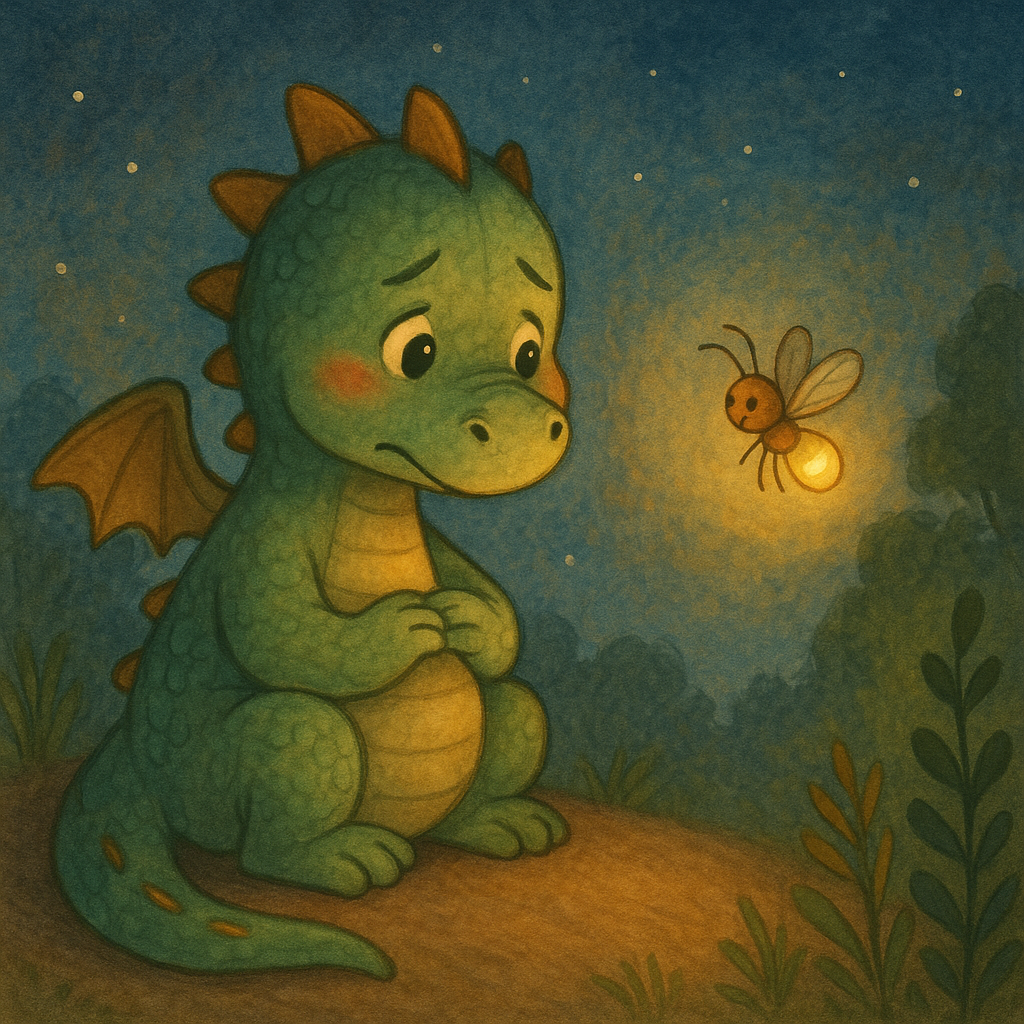

In [5]:
import base64
from IPython.display import Image

picture = client.images.generate(
    model="gpt-image-1",
    prompt=f"A soft, colorful children's storybook illustration of {idea}. "
           "Cozy and warm, no text in the image.",
    size="1024x1024",
)
Image(base64.b64decode(picture.data[0].b64_json))

## Take it further

One idea already gave you a story, a narration, and a picture. A few directions to riff on (good whiteboard fodder, and the API call barely changes):

- **Speak any language.** Translate the story with one more call before narrating it, so the same app reads to any family.
- **Choose your own adventure.** End each part with two options and feed the child's pick back in as the next `idea`.
- **Make a keepsake.** Drop the text and the picture into a printable PDF the child can keep.

Pick one, sketch the pseudocode, and notice how little new code it needs.

### Your turn

Scroll up, change `idea` and `voice`, and run the story, voice, and picture cells again.